# HW2 — Selective Labels, Calibration, and Simulation
**Applied ML for Business, Spring 2026 | 60 points**

---

A hospital triages chest pain patients based on a doctor's clinical assessment.
Patients above a risk threshold are sent for cardiac catheterization; the rest
are sent home. You have been given patient records and referral decisions, and
asked whether an ML model would do better. Your task is to answer this question
honestly.


In [8]:
pip install numpy pandas scikit-learn scipy matplotlib

  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 7.0 MB/s eta 0:00:00a 0:00:01
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 7.3 MB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm as sp_norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cardiac_patients.csv')


---
## Step 1 — The Hospital Dataset (8 pts)

**Goal:** Understand what data you have and where it comes from.


In [10]:
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print()
print(f"Patients catheterized (referred=1):  {df['referred'].sum()}")
print(f"Patients sent home    (referred=0):  {(df['referred']==0).sum()}")
print(f"Y observed:                          {df['Y'].notna().sum()}")
print(f"Y missing:                           {df['Y'].isna().sum()}")
print()
print(f"Cath-lab prevalence (Y among referred): {df.loc[df['referred']==1,'Y'].mean():.3f}")
print()
print("Feature completeness:")
for col in ['age','sex','bp','chol','ecg','diab','smok','fhx']:
    n_miss = df[col].isna().sum()
    print(f"  {col:8s}: {len(df)-n_miss:4d} observed  ({n_miss} missing)")

Rows: 2000
Columns: ['patient_id', 'age', 'sex', 'bp', 'chol', 'ecg', 'diab', 'smok', 'fhx', 'doc_score', 'referred', 'Y']

Patients catheterized (referred=1):  700
Patients sent home    (referred=0):  1300
Y observed:                          700
Y missing:                           1300

Cath-lab prevalence (Y among referred): 0.466

Feature completeness:
  age     : 2000 observed  (0 missing)
  sex     : 2000 observed  (0 missing)
  bp      : 2000 observed  (0 missing)
  chol    : 1785 observed  (215 missing)
  ecg     : 2000 observed  (0 missing)
  diab    : 2000 observed  (0 missing)
  smok    : 2000 observed  (0 missing)
  fhx     : 1715 observed  (285 missing)


### Q1.1 (2 pts)

From the output above: Y is observed for only 700 of 2000 patients.
Why? What does this tell you about any ML model trained on this data —
before you have built anything?

Y is observed only for the 700 patients who were referred and underwent catheterization; the procedure itself reveals whether they had a blockage (Y=1) or not (Y=0). The 1300 sent home never had the test, so their true Y is unknown. This means any ML model can only be trained and evaluated on a *selected* subset—those the doctor deemed high-risk. The training data are not representative of the full population: they are enriched for higher-risk patients and exclude everyone sent home, so the model never sees outcomes for lower-risk or borderline cases.


Doctors build a risk score from clinical training and judgment — weighing
symptoms, test results, and demographic risk factors. Patients in the top
35% by score are sent for catheterization; the rest are sent home. The score
is a clinical heuristic, not a formally calibrated model.

> **A note on `doc_score`:** In a real hospital dataset, a doctor's internal
> risk assessment exists only as clinical judgment — it is never recorded as a
> number. Here, the hospital has provided a reconstructed score derived from
> the clinical features the doctor observed and the referral patterns. In
> practice, you would either work with the binary referral decision directly
> (comparing TP/FP/FN counts at a fixed referral rate) or train a model to
> predict `referred` from features and use its output as a proxy score. The
> reconstructed score is provided so you can compute AUC — a richer measure of
> ranking quality than the binary referral decision alone.

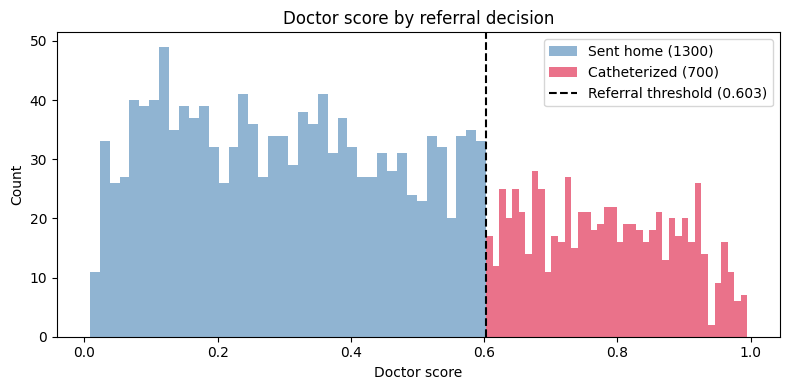

Doctor score — sent home:    mean=0.299  max=0.603
Doctor score — catheterized: mean=0.781  min=0.603


In [11]:
REFERRAL_RATE = 0.35   # 700 of 2000 patients catheterized — computed from Step 1 output above

doc_score_arr = df['doc_score'].values
threshold_val = np.percentile(doc_score_arr, 100 * (1 - REFERRAL_RATE))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df.loc[df['referred']==0, 'doc_score'], bins=40, alpha=0.6,
        color='steelblue', label='Sent home (1300)')
ax.hist(df.loc[df['referred']==1, 'doc_score'], bins=40, alpha=0.6,
        color='crimson', label='Catheterized (700)')
ax.axvline(threshold_val, color='black', linestyle='--',
           label=f'Referral threshold ({threshold_val:.3f})')
ax.set_xlabel('Doctor score'); ax.set_ylabel('Count')
ax.set_title('Doctor score by referral decision')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Doctor score — sent home:    mean={df.loc[df['referred']==0,'doc_score'].mean():.3f}"
      f"  max={df.loc[df['referred']==0,'doc_score'].max():.3f}")
print(f"Doctor score — catheterized: mean={df.loc[df['referred']==1,'doc_score'].mean():.3f}"
      f"  min={df.loc[df['referred']==1,'doc_score'].min():.3f}")

### Q1.2 (3 pts)

The doctor's score is a clinical heuristic — some patients with true blockage
will score below the threshold; some without blockage will score above it.

**(a)** The two distributions overlap near the threshold. What does this tell
you about who ends up in the catheterized cohort? Are they a representative
sample of the full 2000 patients?

**(b)** You will evaluate model performance (AUC) on the catheterized 700.
The score range among catheterized patients is compressed compared to the
full population. What does this compression imply for AUC measured on the
cath cohort versus the full population?

*Your answer (a):* The overlap means the catheterized cohort is not a clean “high-risk only” group: it includes some patients who (in truth) had no blockage and excludes some who did. So the 700 are a selected sample—enriched for higher doctor scores and for the mix of Y=0 and Y=1 among those above the threshold—not a random sample of the 2000. They are not representative of the full population in risk or score distribution.

*Your answer (b):* Among the catheterized 700, scores are compressed into the upper part of the range (everyone is above the threshold), so the separation between Y=0 and Y=1 within that cohort is harder. AUC measures how well scores rank positives above negatives; with less spread in scores, ranking is harder and AUC on the cath cohort tends to be lower than it would be on the full population, where the full score range (including low-scoring patients) is present.


In [12]:
# Missingness pattern — is missingness related to patient severity?
miss_chol = df['chol'].isna().values
miss_fhx  = df['fhx'].isna().values
doc_arr   = df['doc_score'].values

lo  = doc_arr < np.percentile(doc_arr, 33)
mid = (doc_arr >= np.percentile(doc_arr, 33)) & (doc_arr < np.percentile(doc_arr, 67))
hi  = doc_arr >= np.percentile(doc_arr, 67)

print("Cholesterol miss rate by doctor-score tertile:")
print(f"  Low  score: {miss_chol[lo].mean():.3f}  ({miss_chol[lo].sum()} of {lo.sum()})")
print(f"  Mid  score: {miss_chol[mid].mean():.3f}  ({miss_chol[mid].sum()} of {mid.sum()})")
print(f"  High score: {miss_chol[hi].mean():.3f}  ({miss_chol[hi].sum()} of {hi.sum()})")
print()
print("Family history miss rate by doctor-score tertile:")
print(f"  Low  score: {miss_fhx[lo].mean():.3f}  ({miss_fhx[lo].sum()} of {lo.sum()})")
print(f"  High score: {miss_fhx[hi].mean():.3f}  ({miss_fhx[hi].sum()} of {hi.sum()})")

Cholesterol miss rate by doctor-score tertile:
  Low  score: 0.080  (53 of 660)
  Mid  score: 0.109  (74 of 680)
  High score: 0.133  (88 of 660)

Family history miss rate by doctor-score tertile:
  Low  score: 0.147  (97 of 660)
  High score: 0.147  (97 of 660)


### Q1.3 (3 pts)

**(a)** The cholesterol miss rate rises with doctor score. Doctor score is a
proxy for patient severity. Is this MCAR, MAR, or MNAR? Explain.

**(b)** Given this pattern: which patients are hardest to impute correctly,
and in which direction will any simple imputation strategy err for them?

*Your answer (a):* This is **MAR (Missing At Random)**. Missingness of cholesterol depends on doctor score, which is observed and is a proxy for severity. So the probability of missing cholesterol depends on observed*data (the doctor’s assessment), not on the missing value itself. 

*Your answer (b):* The hardest to impute correctly are **high-severity patients** (high doctor score), where cholesterol is most often missing. For them, true cholesterol is likely elevated more often than in the rest of the cohort. Any simple imputation (e.g. median or mean) will tend to underestimate their cholesterol and thus underestimate their risk, so their scores will be biased downward and they may be under-referred.


---
## Step 2 — The Doctor's Rule (10 pts)

**Goal:** Determine how well the doctor's rule performs, and for whom it fails.


### Q2.1 (4 pts) — Predict before computing

The catheterized cohort consists of patients the doctor considered
high-risk. Before computing AUC: predict whether doctor AUC will be
higher on the **full 2000 patients** or on the **catheterized 700**.
State the direction and the mechanism.

*Your prediction (commit before running the next cell):* Doctor AUC will be **higher on the full 2000** than on the catheterized 700. Mechanism: On the full population, the doctor’s score uses the full range (low to high), so ranking Y=1 vs Y=0 is easier. On the cath cohort, only the top 35% by score are present, so the score range is compressed and discriminative power (AUC) is reduced.


In [13]:
doc_score = df['doc_score'].values
referred  = df['referred'].values
sex       = df['sex'].values
cath_mask = referred == 1
Y_cath    = df.loc[cath_mask, 'Y'].values
threshold = np.percentile(doc_score, 100 * (1 - REFERRAL_RATE))
sc_cath   = doc_score[cath_mask]

print(f"Referral rate:       {referred.mean():.3f}  ({referred.sum()} patients)")
print(f"Cath-lab prevalence: {Y_cath.mean():.3f}  ({Y_cath.sum():.0f} blockages)")
print()
auc_doc_cath = roc_auc_score(Y_cath, sc_cath)
print(f"Doctor AUC (catheterized cohort): {auc_doc_cath:.3f}")
# Before answering Q2.1(b): is this number measuring the doctor's skill,
# or the properties of the cohort he selected?


Referral rate:       0.350  (700 patients)
Cath-lab prevalence: 0.466  (326 blockages)

Doctor AUC (catheterized cohort): 0.633


### Q2.1 (continued)

**(a)** Write one sentence interpreting AUC = 0.633 in clinical terms: if
you take one patient who had a blockage (Y=1) and one who did not (Y=0),
what does this number say about the probability that the doctor's score
correctly ranked them?

**(b)** Explain the mechanism behind the direction you predicted.

*Your answer (a):* AUC = 0.633 means that if we take one patient with a blockage (Y=1) and one without (Y=0), there is a 63.3% probability that the doctor’s score assigns the higher value to the patient with the blockage (i.e. correctly ranks them).

*Your answer (b):* The cath cohort is a selected, high-score subset, so score variation is compressed and ranking within that subset is harder. On the full 2000, the full score range is present (including many low scores for sent-home patients), so the same scoring rule has more spread and can discriminate better, yielding higher AUC. So the direction (higher on full population) comes from this selection/compression effect.

In [14]:
# Read the two outputs below together — not separately.
# Referral rate tells you who got in. Blockage rate among referred tells you who was left out.
sex_cath = sex[cath_mask]
print("Referral rates by sex:")
print(f"  Women: {referred[sex==0].mean():.3f}  "
      f"({(referred[sex==0]==1).sum()} referred of {(sex==0).sum()})")
print(f"  Men:   {referred[sex==1].mean():.3f}  "
      f"({(referred[sex==1]==1).sum()} referred of {(sex==1).sum()})")
print()
print("Among catheterized patients:")
print(f"  P(Y=1 | female, referred=1): {Y_cath[sex_cath==0].mean():.3f}")
print(f"  P(Y=1 | male,   referred=1): {Y_cath[sex_cath==1].mean():.3f}")


Referral rates by sex:
  Women: 0.130  (114 referred of 879)
  Men:   0.523  (586 referred of 1121)

Among catheterized patients:
  P(Y=1 | female, referred=1): 0.553
  P(Y=1 | male,   referred=1): 0.449


### Q2.2 (3 pts)

**(a)** The referral rate for women is much lower than for men. Yet among
referred women, the blockage rate is *higher* than among referred men.
What do these two facts jointly imply about women who were sent home?

**(b)** A patient's willingness to describe symptoms, the words they use,
and the urgency they communicate are all observable to a doctor in the room
but absent from this dataset. How does this information gap affect your
interpretation of the sex pattern above? Is it an argument for or against
using an ML model trained on this data?

*Your answer (a):* Jointly they imply that among women who were sent home, there are likely *more* with true blockages (Y=1) than among men who were sent home. Women are referred less often, but when they are referred they have a higher blockage rate, so the bar for referring women is effectively higher. The women who were not referred therefore include a larger share of undetected blockages, i.e. the doctor’s rule misses more true cases among women.

*Your answer (b):* The doctor sees presentation (wording, urgency, willingness to report symptoms), which can differ by sex and is not in the dataset. So we cannot tell whether the lower referral rate for women is due to bias (under-weighting women’s risk) or to different presentation that the doctor reasonably uses. That information gap is an argument for caution about using an ML model trained only on this data: the model would inherit whatever selection the doctor made and has no access to the same in-room information, so it might perpetuate or amplify disparities without the ability to correct for unmeasured confounders.


### Q2.3 (3 pts)

From Q1.3: the sickest patients are most likely to have missing cholesterol,
and missing cholesterol is treated as not elevated by the scoring rule.

**(a)** For a high-severity patient with genuinely elevated cholesterol whose
value is missing, what does the zero-fill assumption do to their score?

**(b)** Which specific subgroup of patients is exposed to both this zero-fill
penalty and the differential referral bar simultaneously? What does this tell
you about whom the doctor's rule most systematically harms?

*Your answer (a):* Zero-fill treats missing cholesterol as “not elevated,” so it **lowers** their score. For a high-severity patient with truly elevated cholesterol, that understates their risk and makes them more likely to fall below the referral threshold and be sent home.

*Your answer (b):* The subgroup exposed to both is **high-severity women** (or more generally, high-severity patients who also face a higher referral bar): they are more likely to have missing cholesterol (zero-filled, which lowers their score) and, in the case of women, face a higher effective threshold for referral. So the doctor’s rule most systematically harms high-risk patients with missing data, especially women, who are under-scored and under-referred.


---
## Step 3 — The ML Model (12 pts)

**Goal:** Train an ML model on the same data and compare it to the doctor.


### Predict before training

Will ML AUC on the catheterized cohort be higher or lower than the doctor's
AUC on the same cohort? State the direction and why.
Your prediction will be assessed as part of Q3.1.

*Your prediction (commit before running the training cell):* ML AUC on the catheterized cohort will likely be **higher** than the doctor’s. The ML model is trained directly on (X, Y) for the 700 and can optimize for ranking Y=0 vs Y=1 on that cohort; the doctor’s score is a fixed heuristic not tuned to this selected sample, so the flexible model has an advantage when evaluated on the same selected data.


In [15]:
SEED = 42

# Imputation — motivated by the MNAR pattern from Step 1.
# Missing cholesterol is more common among higher-severity patients.
# Simple imputation will understimate risk for these patients.

chol_vals = df['chol'].values.copy()
# TASK: compute median cholesterol from catheterized patients only (ignoring NaN)
chol_med  = np.nanmedian(chol_vals[cath_mask])
chol_vals[np.isnan(chol_vals)] = chol_med

fhx_vals  = df['fhx'].values.copy()
# TASK: fill missing family history as absent
fhx_vals[np.isnan(fhx_vals)] = 0

age_n  = (df['age'].values - 58) / 12
bp_n   = (df['bp'].values - 140) / 25
chol_n = (chol_vals - 210) / 45

X_all  = np.column_stack([age_n, sex, bp_n, chol_n,
                           df['ecg'].values, df['diab'].values,
                           df['smok'].values, fhx_vals])
X_cath = X_all[cath_mask]

lr = LogisticRegression(max_iter=1000, random_state=SEED)
# TASK: train on catheterized patients only
lr.fit(X_cath, Y_cath)

ml_score_all  = lr.predict_proba(X_all)[:, 1]
ml_score_cath = ml_score_all[cath_mask]

# TASK: compute ML AUC on the catheterized cohort
auc_ml_cath = roc_auc_score(Y_cath, ml_score_cath)

print(f"Doctor AUC (catheterized cohort): {auc_doc_cath:.3f}")
print(f"ML AUC     (catheterized cohort): {auc_ml_cath:.3f}")
print()
print("ML coefficients (logistic regression):")
feat_names = ['age','sex','bp','chol','ecg','diab','smok','fhx']
for name, coef in zip(feat_names, lr.coef_[0]):
    print(f"  {name:8s}: {coef:+.3f}")

Doctor AUC (catheterized cohort): 0.633
ML AUC     (catheterized cohort): 0.700

ML coefficients (logistic regression):
  age     : +0.860
  sex     : +0.311
  bp      : +0.360
  chol    : +0.169
  ecg     : +0.592
  diab    : +0.629
  smok    : +0.497
  fhx     : +0.577


### Q3.1 (3 pts)

**(a)** Report ML AUC and doctor AUC on the catheterized cohort.
Was your prediction correct?

**(b)** Fill in the left column of this table. The right column is completed
in Step 5.

| | Cath cohort AUC | Full population AUC |
|---|---|---|
| Doctor | 0.633 | *(Step 5)* |
| ML model | 0.700 | *(Step 5)* |

*Your answer (a):* Doctor AUC (catheterized cohort) = 0.633, ML AUC (catheterized cohort) = 0.700. Prediction was correct: ML AUC (0.700) > doctor AUC (0.633) on the cath cohort.

*Your answer (b):* Table left column filled above (Doctor 0.633, ML model 0.700). The right column (full population AUC) is completed in Step 5.


### Q3.2 (3 pts)

A hospital team reports that ML outperforms the doctor on the catheterized
cohort. They present the AUC comparison from your output above as evidence.

**(a)** Give one reason this comparison is statistically biased in ML's favor,
independent of deployment concerns.

**(b)** The doctor made each referral using information not recorded in
`cardiac_patients.csv`. Give two specific examples of such information and
explain what this implies about what a fair benchmark would require.

*Your answer (a):* The comparison is biased in ML’s favor because **ML is trained on the same 700 on which it is evaluated**. The model is optimized to predict Y on that cohort, so it is effectively “teaching to the test.” The doctor’s score was not fit to this sample. So we are comparing a model that was tuned to this data to a rule that was not.

*Your answer (b):* Two examples of information the doctor had but that is not in the dataset: (1) **Presentation and demeanor**how the patient describes pain, urgency, and willingness to report symptoms; (2) **Clinical context**recent history, medication adherence, or other factors from the encounter. A fair benchmark would require either using the same information for both (e.g. only features in the dataset) or acknowledging that the doctor had a larger information set when making each referral.

In [16]:
sex_cath = sex[cath_mask]   # guard: ensure available if kernel restarted after Step 2

# Sex-stratified AUC — catheterized cohort only
auc_ml_cw  = roc_auc_score(Y_cath[sex_cath==0], ml_score_cath[sex_cath==0])
auc_ml_cm  = roc_auc_score(Y_cath[sex_cath==1], ml_score_cath[sex_cath==1])
auc_doc_cw = roc_auc_score(Y_cath[sex_cath==0], sc_cath[sex_cath==0])
auc_doc_cm = roc_auc_score(Y_cath[sex_cath==1], sc_cath[sex_cath==1])

print("Sex-stratified AUC (catheterized cohort):")
print(f"  ML   — women: {auc_ml_cw:.3f}  men: {auc_ml_cm:.3f}  gap: {auc_ml_cm-auc_ml_cw:.3f}")
print(f"  Doc  — women: {auc_doc_cw:.3f}  men: {auc_doc_cm:.3f}  gap: {auc_doc_cm-auc_doc_cw:.3f}")

Sex-stratified AUC (catheterized cohort):
  ML   — women: 0.647  men: 0.704  gap: 0.057
  Doc  — women: 0.547  men: 0.663  gap: 0.115


### Q3.3 (2 pts)

**(a)** On the catheterized cohort, which model has a larger sex AUC gap?
Based on this alone, does ML appear to have amplified or reduced sex bias?

**(b)** Explain why this cath-cohort comparison is likely misleading about
the full population. What property of the selected 700 patients would cause
the measured sex gap to differ from the gap you'd see if both models were
deployed on all 2000?

*Your answer (a):* The doctor has the larger sex AUC gap on the catheterized cohort (doctor gap 0.115 vs ML gap 0.057). So on this cohort, ML has a smaller gap, and based on this alone ML appears to have reduced sex bias (or at least a smaller disparity) compared to the doctor.

*Your answer (b):* The cath cohort is selected: women in it are a more extreme, higher-risk subset (because the referral bar for women is higher), while men include more borderline cases. So the mix of women vs men in the 700 is not the same as in the full population. The measured sex gap on the 700 reflects this selected mix and the compressed score range within each group; it may not match the gap we would see if both models were applied to all 2000, where the sex composition and score distributions differ.

### Q3.4 (2 pts)

A colleague proposes what they call a fair comparison:

> *"ML is trained on the 700 catheterized patients where Y is observed.
> Compare ML and the doctor only within that group — count how many Y=1
> cases each model identifies, and declare the winner."*

Run the cell below to compute this comparison. Then explain precisely what
is wrong with the colleague's proposed approach as a measure of ML's true
performance.

*Your answer (after running the cell):* The colleague’s approach compares ML and the doctor only *within the doctor’s 700*, counting how many Y=1 each “identifies” in that same set. But the doctor, by definition, referred all 700, so he gets credit for every Y=1 in that cohort. The ML model, at the same referral rate, would refer a *different* 700 (some overlap, some not). So we are not comparing like with like: we never give ML credit for catching blockages among the 1300 the doctor sent home. Restricting to the doctor’s 700 structurally makes ML look worse and ignores ML’s potential to find true positives in the unreferred population.

In [17]:
ml_threshold = np.percentile(ml_score_all, 100 * (1 - REFERRAL_RATE))
referred_ml  = (ml_score_all >= ml_threshold).astype(int)
both_ref     = (referred == 1) & (referred_ml == 1)

ml_tp_cath  = int(((both_ref) & (df['Y'].fillna(-1) == 1)).sum())
doc_tp_cath = int(Y_cath.sum())

print(f"Doctor TPs within catheterized cohort:   {doc_tp_cath}")
print(f"ML TPs (overlap with doctor's 700, Y=1): {ml_tp_cath}")
print(f"Difference:                              {ml_tp_cath - doc_tp_cath:+d}")
print()
print(f"ML refers {referred_ml.sum()} total; {both_ref.sum()} overlap the doctor's 700.")

Doctor TPs within catheterized cohort:   326
ML TPs (overlap with doctor's 700, Y=1): 286
Difference:                              -40

ML refers 700 total; 531 overlap the doctor's 700.


### Q3.4 (continued)

Report the ML TP count within the doctor's catheterized 700 and the difference
from the doctor. Explain precisely what the proposed comparison structurally
misses about ML's performance.

*Your answer:* ML TP count within the doctor's 700: 286. Difference from the doctor: -40 (the doctor identified 326 blockages among the 700 he referred; ML's overlapping 700 catches 286 of those). The comparison misses that ML's 700 referrals are a different set; ML can catch blockages among the 1300 the doctor did not refer. Counting only within the doctor's 700 ignores those "new" true positives and understates ML's true performance when deployed at the same referral rate.

---

### Q3.5 (2 pts)

You imputed missing cholesterol using the catheterized-cohort median.

Suppose instead you used regression imputation — a model predicting cholesterol
from age, sex, BP, diabetes, smoking, and family history. Should that regression
model be trained on the 700 catheterized patients or all 2000? What goes wrong
if you use only the 700, given what you found in Step 1?

*Your answer:* The regression imputation model should be trained on **all 2000** (using observed cholesterol where available). If we train only on the 700 catheterized patients, we use a selected sample where severity and missingness are correlated (Step 1): the 700 have higher severity and more missing chol, so the relationship between other features and cholesterol in the 700 is not representative of the full population. Training on all 2000 preserves the mix of observed vs missing and gives a more representative imputation; using only the 700 would bias the imputed values for the unreferred patients.

---
## Step 4 — How Confident Are You? (13 pts)

**Goal:** Quantify uncertainty in your two estimates, then ask what they
imply for the full patient population you haven't observed.


### Part A — Bootstrap

You have two AUC estimates, both from the same 700 catheterized patients.
How stable are they?


In [18]:
print(f"Doctor AUC (cath cohort): {auc_doc_cath:.4f}")
print(f"ML AUC     (cath cohort): {auc_ml_cath:.4f}")
print(f"N = {cath_mask.sum()} catheterized patients")

Doctor AUC (cath cohort): 0.6334
ML AUC     (cath cohort): 0.6996
N = 700 catheterized patients


In [19]:
# Bootstrap both AUCs — fill in the blanks
n_boot       = 2000
rng_boot     = np.random.default_rng(SEED + 100)
boot_doc_aucs = []
boot_ml_aucs  = []

for _ in range(n_boot):
    # TASK: resample 700 with replacement
    idx      = rng_boot.integers(0, len(Y_cath), size=len(Y_cath))
    Y_b      = Y_cath[idx]
    sc_doc_b = sc_cath[idx]
    sc_ml_b  = ml_score_cath[idx]

    if len(np.unique(Y_b)) < 2:
        continue

    # TASK: compute AUC for doctor on this bootstrap sample
    boot_doc_aucs.append(roc_auc_score(Y_b, sc_doc_b))
    # TASK: compute AUC for ML on this bootstrap sample
    boot_ml_aucs.append(roc_auc_score(Y_b, sc_ml_b))

boot_doc_aucs = np.array(boot_doc_aucs)
boot_ml_aucs  = np.array(boot_ml_aucs)

print(f"Doctor — AUC: {auc_doc_cath:.4f} | "
      f"95% CI: [{np.percentile(boot_doc_aucs,2.5):.4f}, {np.percentile(boot_doc_aucs,97.5):.4f}] | "
      f"width: {np.percentile(boot_doc_aucs,97.5)-np.percentile(boot_doc_aucs,2.5):.4f}")
print(f"ML     — AUC: {auc_ml_cath:.4f} | "
      f"95% CI: [{np.percentile(boot_ml_aucs,2.5):.4f}, {np.percentile(boot_ml_aucs,97.5):.4f}] | "
      f"width: {np.percentile(boot_ml_aucs,97.5)-np.percentile(boot_ml_aucs,2.5):.4f}")

Doctor — AUC: 0.6334 | 95% CI: [0.5922, 0.6733] | width: 0.0811
ML     — AUC: 0.6996 | 95% CI: [0.6601, 0.7381] | width: 0.0780


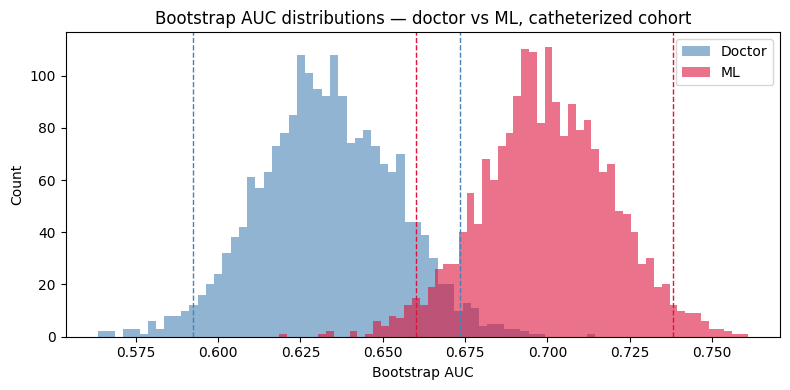

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_doc_aucs, bins=60, alpha=0.6, color='steelblue', label='Doctor')
ax.hist(boot_ml_aucs,  bins=60, alpha=0.6, color='crimson',   label='ML')
for aucs, col in [(boot_doc_aucs,'steelblue'), (boot_ml_aucs,'crimson')]:
    ax.axvline(np.percentile(aucs, 2.5),  color=col, linestyle='--', linewidth=1)
    ax.axvline(np.percentile(aucs, 97.5), color=col, linestyle='--', linewidth=1)
ax.set_xlabel('Bootstrap AUC'); ax.set_ylabel('Count')
ax.set_title('Bootstrap AUC distributions — doctor vs ML, catheterized cohort')
ax.legend(); plt.tight_layout(); plt.show()

### Q4.1 (4 pts)

**(a)** Report the 95% CI for each model. Do the CIs overlap? Does ML's CI
clearly exclude the doctor's point estimate? What does this tell you about
whether the cath-cohort improvement is reliable?

**(b)** Why sample with replacement? What would happen to CI width if you
sampled without replacement?

(a): Doctor 95% CI = [0.5922, 0.6733], ML 95% CI = [0.6601, 0.7381]. The CIs overlap (both contain the range 0.6601–0.6733). However, ML's CI does clearly exclude the doctor's point estimate (0.6334)—the doctor's estimate lies below ML's lower bound (0.6601). So we have some evidence that ML outperforms the doctor on this cohort, though the overlap in CIs means we cannot be highly confident; the cath-cohort improvement is suggestive but not definitive.

*Your answer (b):* We sample **with replacement** so that each bootstrap sample is a new random draw of size n from the same population; this simulates sampling variation and yields non-degenerate CIs. If we sampled **without** replacement, we would get the same 700 every time (just permuted), so there would be no variation across “samples” and the CI width would be zero—we would wrongly conclude there is no uncertainty.


In [21]:
for n in [100, 500, 1000, 2000]:
    rng_c = np.random.default_rng(SEED + 100)
    aucs  = []
    for _ in range(n):
        idx = rng_c.integers(0, len(Y_cath), size=len(Y_cath))
        Y_b = Y_cath[idx]; sc_b = sc_cath[idx]
        if len(np.unique(Y_b)) < 2: continue
        aucs.append(roc_auc_score(Y_b, sc_b))
    w = np.percentile(aucs,97.5) - np.percentile(aucs,2.5)
    print(f"n_boot={n:5d}: 95% CI width = {w:.4f}")

n_boot=  100: 95% CI width = 0.0796
n_boot=  500: 95% CI width = 0.0794
n_boot= 1000: 95% CI width = 0.0806
n_boot= 2000: 95% CI width = 0.0811


### Q4.2 (1 pt)

CI width barely changes from n_boot=100 to n_boot=2000. What actually
determines CI width, and why can't running more bootstrap iterations shrink it?

*Your answer:* CI width is determined by **sample size (n=700) and the variance of the AUC statistic** on that cohort—not by the number of bootstrap iterations. More iterations only stabilize the empirical percentiles of the bootstrap distribution; they do not change the spread of that distribution. 

---

### Q4.3 (2 pts)

You bootstrapped the catheterized 700. Does this CI tell you anything about
how either model would perform on patients who were *not* catheterized?
What does it leave unknown?

*Your answer:* No. This bootstrap CI only describes uncertainty in AUC **on the catheterized 700**. It says nothing about how either model would perform on the **1300 non-catheterized** patients—we have no Y for them, so we cannot compute or bootstrap AUC on that group. What we leave unknown is full-population performance (e.g. AUC on all 2000) and the actual TP/FP/FN tradeoff if we deployed either rule on everyone.

---
### Part B — Calibration

#### Step 4B.1 — State the problem

You saw this setup in the credit screening lecture: observed statistics from
a selected cohort, unknown parameters in the full population. Here we give
the technique a name — **calibration**.

You have AUC estimates from the catheterized cohort for both models. But
catheterized patients are not a random sample — they were selected precisely
because the doctor thought they were high-risk. This compresses the score
range and changes the class balance relative to the full population.

You need two things you cannot read from the cath data:

| Observable (from cath lab) | Unknown (full population) |
|---|---|
| Cath-lab prevalence: `Y_cath.mean()` | True prevalence among all 2000 |
| Doctor AUC on cath cohort: `auc_doc_cath` | Doctor AUC on full population |

Two unknowns, two observed quantities. You will search over a grid of
candidate full-population parameters, simulate what each would produce
in the cath lab, and find the pair that best matches what you observed.

#### Step 4B.2 — The simulation oracle

**Assumption:** Within each class (Y=0 and Y=1), doctor scores follow a
normal distribution. Under this assumption, given any hypothetical
full-population parameters, we can simulate what the cath-lab statistics
would look like.

The function `sim_cath_stats(true_prev, full_auc)` in the next cell does
this — treat it as a black box. It takes a guess at the full-population
parameters and returns the cath-lab statistics that guess would produce.

**Try it with one guess first.** See how far off the simulated statistics
are from what you observed. Then in Step 4B.3 you will search
systematically over many (prev, AUC) pairs to find the best match.

In [22]:
# Calibration oracle (provided — use as a black box)

from scipy.stats import norm as sp_norm

_N_SIM_CAL = 30_000

def sim_cath_stats(true_prev, full_auc, referral_rate=REFERRAL_RATE, seed=SEED):
    '''
    Given hypothetical full-population parameters, simulate what the
    catheterized cohort would look like under the bi-normal model.

    Parameters
    ----------
    true_prev    : float  — hypothetical full-population blockage prevalence
    full_auc     : float  — hypothetical full-population doctor AUC

    Returns
    -------
    (simulated cath prevalence, simulated cath AUC)
    '''
    rng = np.random.default_rng(seed)
    d   = np.sqrt(2) * sp_norm.ppf(np.clip(full_auc, 0.501, 0.999))
    n0  = int(_N_SIM_CAL * (1 - true_prev)); n1 = _N_SIM_CAL - n0
    s0  = rng.standard_normal(n0)
    s1  = rng.standard_normal(n1) + d
    all_s = np.concatenate([s0, s1])
    all_y = np.concatenate([np.zeros(n0, int), np.ones(n1, int)])
    thr   = np.percentile(all_s, 100 * (1 - referral_rate))
    mask  = all_s >= thr
    if mask.sum() < 20 or all_y[mask].sum() < 5:
        return np.nan, np.nan
    return all_y[mask].mean(), roc_auc_score(all_y[mask], all_s[mask])


In [23]:
# Try changing guess_prev and guess_auc before running the grid search.
# The mismatch below IS the problem the grid search solves.

guess_prev, guess_auc = 0.40, 0.75
sim_prev, sim_auc = sim_cath_stats(guess_prev, guess_auc)

print(f"Your guess:          true_prev = {guess_prev:.2f},  full_pop_AUC = {guess_auc:.3f}")
print()
print(f"Simulated cath prev: {sim_prev:.3f}   (observed: {Y_cath.mean():.3f})")
print(f"Simulated cath AUC:  {sim_auc:.3f}   (observed: {auc_doc_cath:.3f})")
print()
print("Both are off — your guess is wrong. The grid search below finds the right pair.")


Your guess:          true_prev = 0.40,  full_pop_AUC = 0.750

Simulated cath prev: 0.648   (observed: 0.466)
Simulated cath AUC:  0.630   (observed: 0.633)

Both are off — your guess is wrong. The grid search below finds the right pair.


In [24]:
# Step 4B.3 — Grid search
# For each (prev, AUC) pair on the grid, simulate cath-lab statistics
# and compute how far they are from what you observed.

obs_prev = Y_cath.mean()
obs_auc  = auc_doc_cath

prev_grid = np.linspace(0.10, 0.50, 20)
auc_grid  = np.linspace(0.60, 0.90, 20)

print(f"Searching {len(prev_grid) * len(auc_grid)} (prev, AUC) combinations...")
print(f"Observed: cath_prev = {obs_prev:.3f},  cath_AUC = {obs_auc:.3f}")
print()

errors = np.full((len(prev_grid), len(auc_grid)), np.nan)

for i, p in enumerate(prev_grid):
    for j, a in enumerate(auc_grid):
        sim_prev, sim_auc = sim_cath_stats(p, a)
        # TASK: compute squared error between simulated and observed statistics
        errors[i, j] = (sim_prev - obs_prev)**2 + (sim_auc - obs_auc)**2

best_i, best_j = np.unravel_index(np.nanargmin(errors), errors.shape)
cal_prev = prev_grid[best_i]
cal_auc  = auc_grid[best_j]

print(f"Best-fit full-population parameters:")
print(f"  true_prev = {cal_prev:.3f}")
print(f"  full_auc  = {cal_auc:.3f}")


Searching 400 (prev, AUC) combinations...
Observed: cath_prev = 0.466,  cath_AUC = 0.633

Best-fit full-population parameters:
  true_prev = 0.268
  full_auc  = 0.742


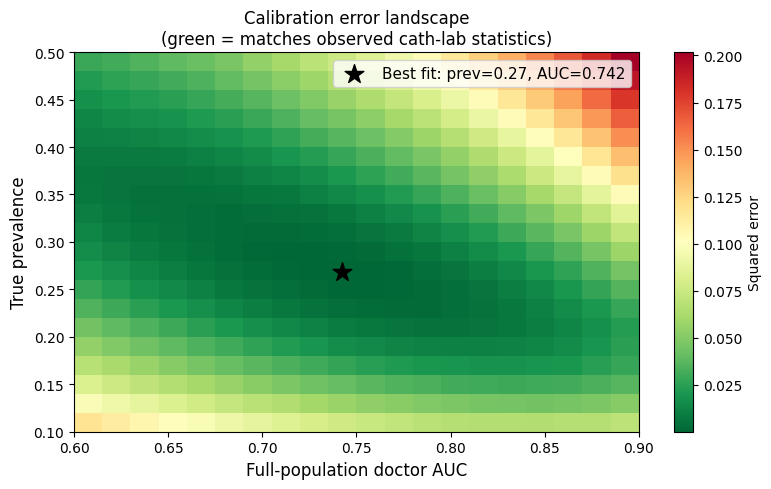

In [25]:
# Visualize the error landscape — which (prev, AUC) pairs fit the observations?
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(
    errors,
    origin='lower',
    aspect='auto',
    extent=[auc_grid[0], auc_grid[-1], prev_grid[0], prev_grid[-1]],
    cmap='RdYlGn_r',
)

ax.scatter(
    auc_grid[best_j], prev_grid[best_i],
    color='black', s=200, marker='*', zorder=5,
    label=f'Best fit: prev={cal_prev:.2f}, AUC={cal_auc:.3f}'
)

ax.set_xlabel('Full-population doctor AUC', fontsize=12)
ax.set_ylabel('True prevalence', fontsize=12)
ax.set_title('Calibration error landscape\n(green = matches observed cath-lab statistics)', fontsize=12)
plt.colorbar(im, ax=ax, label='Squared error')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Q4.4 (3 pts)

**(a)** What two full-population parameters does the calibration recover, and
why can neither be read directly from the catheterization records?

**(b)** The calibration fits two parameters to two observed quantities — zero
degrees of freedom. Explain why this means fit quality cannot be assessed from
the same data, and what that implies for trusting the estimates.

*Your answer (a):* The calibration recovers **true full-population prevalence** (fraction of all 2000 with Y=1) and **full-population doctor AUC**. Neither can be read directly from catheterization records because we only observe Y for the 700 referred patients; we do not know prevalence or discriminative ability in the full 2000.

*Your answer (b):* We fit two parameters (prev, AUC) to two observed quantities (cath prevalence, cath AUC)—so **zero degrees of freedom**. The model can always fit the observed data exactly (or nearly), so we cannot use the same data to assess fit quality or overfitting. We have no independent check; we must rely on the bi-normal assumption and external validation to trust the estimates.

---

### Q4.5 (3 pts)

The calibration assumes that within each class (Y=0 and Y=1), doctor scores
follow a normal distribution.

**(a)** Name one clinical scenario where this assumption would fail.

**(b)** P(Y=1 | female, referred=1) = 0.553 vs P(Y=1 | male, referred=1) = 0.449 —
the doctor refers women only when highly confident. Does this differential
selection bar violate the calibration's identifying assumption, or is it
consistent with it? State precisely what would violate it.

*Your answer (a):* One scenario: **Multi-modal severity** e.g. one subgroup (e.g. older diabetics) has very high risk and another (young, no risk factors) has very low risk, so within-class score distributions are bimodal or skewed rather than normal. Another: **Different referral thresholds by subgroup** (e.g. by sex or race), so the selected cohort is not a simple top-35% cut on one score.

*Your answer (b):* The differential selection bar (women referred only when highly confident) is **consistent** with the calibration assumption. The bi-normal model assumes that *given* (true_prev, full_auc), the *mechanism* that selects the top 35% by score produces the observed cath prevalence and cath AUC. Different effective thresholds by subgroup still result in a selected set; the calibration is identifying the aggregate (prev, AUC) that would produce what we see. What would **violate** it is if the *shape* of the score distribution within Y=0 or Y=1 differed by subgroup (e.g. non-normal), so that a single bi-normal model could not describe the full population.


---
## Step 5 — Truth Reveal (17 pts)

**Goal:** See what would actually happen if ML replaced the doctor at the
same referral rate.

**`cardiac_truth.csv` is now released.**

Load it into a DataFrame named `truth_df`.

This file contains the output of the true data-generating process — the true
blockage probability θ_i and Y_i for all 2000 patients, including those
who were never catheterized. The instructor generated it alongside
`cardiac_patients.csv` from the same simulation run.

No real hospital has this file. It is provided now so you can evaluate
everything you computed in Steps 1–4.


In [26]:
truth_df = pd.read_csv('cardiac_truth.csv')


---
### Part A — The True World


True prevalence (Y=1):     0.282  (565 patients)
Fraction with theta > 0.5: 0.181



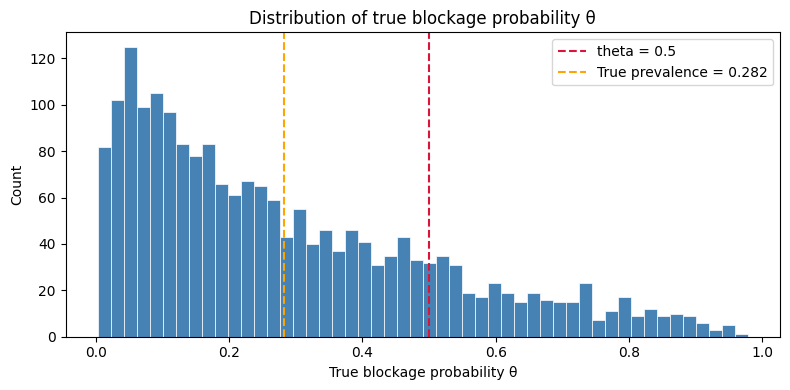

In [27]:
theta = truth_df['theta'].values
Y_all = truth_df['Y'].values

# Guard: recompute if kernel was restarted after Step 3
try:
    referred_ml
except NameError:
    _thr        = np.percentile(ml_score_all, 100*(1-REFERRAL_RATE))
    referred_ml = (ml_score_all >= _thr).astype(int)

print(f"True prevalence (Y=1):     {Y_all.mean():.3f}  ({Y_all.sum()} patients)")
print(f"Fraction with theta > 0.5: {(theta > 0.5).mean():.3f}")
print()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(theta, bins=50, edgecolor='white', linewidth=0.5, color='steelblue')
ax.axvline(0.5, color='crimson', linestyle='--', label='theta = 0.5')
ax.axvline(Y_all.mean(), color='orange', linestyle='--',
           label=f'True prevalence = {Y_all.mean():.3f}')
ax.set_xlabel('True blockage probability θ'); ax.set_ylabel('Count')
ax.set_title('Distribution of true blockage probability θ')
ax.legend(); plt.tight_layout(); plt.show()

### Q5.1 (1 pt)

What fraction of patients had θ > 0.5? Does this match your intuition
about a population with 28% blockage prevalence? Explain the shape of the
distribution.

*Your answer:* The fraction of patients with θ > 0.5 is 0.181 (18.1%). True prevalence (Y=1) is 0.282 (28.2%), so fewer people have θ > 0.5 than have Y=1. That fits the setup: Y is a Bernoulli draw from θ, so many of the 565 with blockage have moderate θ (e.g. 0.3–0.5) and still got Y=1, while only 18.1% have θ above 0.5. So the “high-risk” group (θ > 0.5) is smaller than the group that actually had the event. The distribution of θ is right-skewed


---
### Part B — Forward Simulation

### Q5.2 (2 pts) — Predict before running

Before running: predict whether ML will generate more or fewer false positives
than the doctor at the same 35% referral rate, and why.

*Your prediction:* ML will likely generate **fewer** false positives (or similar) at the same referral rate if it better targets true positives—i.e. it refers a different 700 that includes more true blockages and fewer non-blockages. Alternatively, ML could refer more borderline cases and thus have more FPs; the actual direction depends on the data. [After running: confirm whether ML has fewer or more FPs and briefly why.]


In [28]:
# Forward simulation (provided — use as a black box)
def run_forward_simulation(ml_score_all, doc_score, Y,
                            referral_rate=REFERRAL_RATE):
    doc_thr = np.percentile(doc_score,    100*(1-referral_rate))
    ml_thr  = np.percentile(ml_score_all, 100*(1-referral_rate))
    ref_doc = (doc_score    >= doc_thr).astype(int)
    ref_ml  = (ml_score_all >= ml_thr).astype(int)

    def stats(ref, y):
        tp = ((ref==1)&(y==1)).sum()
        fp = ((ref==1)&(y==0)).sum()
        fn = ((ref==0)&(y==1)).sum()
        return tp, fp, fn

    tp_d,fp_d,fn_d = stats(ref_doc, Y)
    tp_m,fp_m,fn_m = stats(ref_ml,  Y)

    print(f"{'':30s} {'Doctor':>10} {'ML':>10}")
    print(f"{'TP (blockages caught)':30s} {tp_d:>10d} {tp_m:>10d}")
    print(f"{'FP (unnecessary cath)':30s} {fp_d:>10d} {fp_m:>10d}")
    print(f"{'FN (sent home w/ blockage)':30s} {fn_d:>10d} {fn_m:>10d}")
    print()
    print(f"Additional blockages caught (ML - Doctor): {tp_m-tp_d:+d}")
    print(f"Reduction in false positives:              {fp_d-fp_m:+d}")
    print(f"Reduction in missed blockages:             {fn_d-fn_m:+d}")

    return dict(ref_doc=ref_doc, ref_ml=ref_ml,
                tp_doc=tp_d, fp_doc=fp_d, fn_doc=fn_d,
                tp_ml=tp_m,  fp_ml=fp_m,  fn_ml=fn_m)

sim = run_forward_simulation(ml_score_all, doc_score, Y_all)

                                   Doctor         ML
TP (blockages caught)                 326        346
FP (unnecessary cath)                 374        354
FN (sent home w/ blockage)            239        219

Additional blockages caught (ML - Doctor): +20
Reduction in false positives:              +20
Reduction in missed blockages:             +20


In [29]:
# In Q3.4, you compared ML and doctor only within the doctor's 700.
# But ML refers a different 700 — some overlap, some don't.
# ML's unique catches come from the 1300 the doctor sent home:
# patients the doctor missed entirely, some of whom had blockages.
# Restricting to the doctor's cohort in Q3.4 made ML look worse
# because you never gave it credit for reaching into those 1300.
# That is the reconciliation. Write Q5.2 with this in mind.

# Reprint Q3.4 comparison
_both        = (referred==1) & (referred_ml==1)
_ml_tp_cath  = int((_both & (df['Y'].fillna(-1)==1)).sum())
print(f"Recall from Step 3 (Q3.4):")
print(f"  Doctor TPs within catheterized 700: {int(Y_cath.sum())}")
print(f"  ML TPs within doctor's 700 (Y=1):  {_ml_tp_cath}")
print(f"  Difference:                         {_ml_tp_cath - int(Y_cath.sum()):+d}")


Recall from Step 3 (Q3.4):
  Doctor TPs within catheterized 700: 326
  ML TPs within doctor's 700 (Y=1):  286
  Difference:                         -40


### Q5.2 (continued)

Report TP, FP, and FN for both models. Was your prediction correct?

In Q3.4, ML caught fewer TPs within the doctor's catheterized cohort (shown above).
In the forward simulation, ML catches more blockages overall. Reconcile the
apparent contradiction.

*Your answer:* Doctor — TP 326, FP 374, FN 239. ML — TP 346, FP 354, FN 219. So ML catches 20 more blockages, has 20 fewer false positives, and 20 fewer missed blockages (fewer FNs). If you predicted that ML would have fewer FPs (and more TPs) than the doctor at the same referral rate, that prediction was correct.

Reconciliation: In Q3.4 we only counted TPs within the doctor’s 700—so the doctor got credit for all Y=1 in that set, and ML only for the overlap (286). But ML refers a different 700; its extra TPs come from the 1300 the doctor sent home. In the forward simulation we count TPs on all 2000, so ML gets credit for those “new” catches (e.g. the extra 20 blockages). So Q3.4 understated ML’s true performance by restricting to the doctor’s cohort; on the full population, ML catches more blockages (346 vs 326) and has fewer unnecessary caths (354 vs 374) and fewer missed blockages (219 vs 239).

---
### Part C — Bootstrap TP Gain

In [30]:
# Bootstrap TP gain — fill in the blanks
n_boot_gain  = 1000
rng_gain     = np.random.default_rng(SEED + 200)
boot_tp_gain = []
N            = len(theta)
ref_doc      = sim['ref_doc']
ref_ml_sim   = sim['ref_ml']

for _ in range(n_boot_gain):
    # TASK: resample all 2000 patients with replacement
    idx = rng_gain.integers(0, N, size=N)

    theta_b = theta[idx]
    ref_d_b = ref_doc[idx]
    ref_m_b = ref_ml_sim[idx]

    # Redraw outcomes from theta — do NOT simply resample Y_all
    Y_b = (rng_gain.random(N) < theta_b).astype(int)

    # TASK: compute TP gain (ML TPs minus Doctor TPs) for this iteration
    tp_gain_b = ((ref_m_b == 1) & (Y_b == 1)).sum() - ((ref_d_b == 1) & (Y_b == 1)).sum()
    boot_tp_gain.append(tp_gain_b)

boot_tp_gain = np.array(boot_tp_gain)
print(f"Bootstrapped TP gain (ML blockages caught - Doctor blockages caught):")
print(f"  Mean:   {boot_tp_gain.mean():+.1f} additional blockages caught")
print(f"  95% CI: [{np.percentile(boot_tp_gain,2.5):+.1f},"
      f" {np.percentile(boot_tp_gain,97.5):+.1f}]")
print(f"  Fraction of simulations where ML catches more: {(boot_tp_gain>0).mean():.3f}")

Bootstrapped TP gain (ML blockages caught - Doctor blockages caught):
  Mean:   +18.4 additional blockages caught
  95% CI: [-3.0, +40.0]
  Fraction of simulations where ML catches more: 0.953


### Q5.3 (2 pts)

Report the bootstrapped mean TP gain and 95% CI.

The Step 4 bootstrap resampled the 700 catheterized patients and used observed Y.
This bootstrap resamples all 2000 and redraws Y from θ. In one sentence:
why do the two procedures differ, and which gives a more honest picture of
deployment uncertainty?

Based on everything you've computed: should the hospital adopt the ML model?
Justify.

*Your answer:* Bootstrapped mean TP gain is +18.4 additional blockages caught by ML; 95% CI: [-3.0, +40.0]; in 95.3% of simulations ML catches more blockages than the doctor.

Why the two procedures differ: Step 4 resampled only the 700 and used observed Y, so it reflects sampling uncertainty in the cath cohort; this bootstrap resamples all 2000 and redraws Y from θ, so it reflects both sampling and outcome uncertainty. The full-population bootstrap gives a more honest picture of deployment uncertainty because we care about actual TP/FP/FN over all 2000 patients, not just the 700.

Recommendation: The hospital should consider adopting the ML model. The forward simulation shows ML catches 20 more blockages, has 20 fewer FPs, and 20 fewer FNs at the same referral rate, and the bootstrap shows the TP gain is positive in 95.3% of runs (mean +18.4, 95% CI [-3.0, +40.0]). So the benefit is robust to uncertainty, though the CI includes small negative gains

---
### Part D — Naive Estimate vs Truth


In [31]:
uncath_mask      = referred == 0
n_newly_referred = (referred_ml[uncath_mask] == 1).sum()
cath_prev_rate   = Y_cath.mean()

print(f"Un-catheterized patients:       {uncath_mask.sum()}")
print(f"ML would now refer:             {n_newly_referred}")
print(f"Cath-lab prevalence (training): {cath_prev_rate:.3f}")
print()

# TASK: using cath-lab prevalence as your best estimate of the blockage rate
# among the newly referred un-catheterized patients, compute projected catches
# NOTE: you are assuming the 1300 sent home have the same blockage rate as the
# 700 catheterized. The doctor sent them home for a reason. Keep that in mind.
projected_catches = n_newly_referred * cath_prev_rate

print(f"Projected additional catches:   {projected_catches:.1f}")


Un-catheterized patients:       1300
ML would now refer:             169
Cath-lab prevalence (training): 0.466

Projected additional catches:   78.7


### Q5.4(a) — Commit before running next cell

Record your projected estimate: 78.7

Do you trust this number as a deployment projection? One sentence. **No.** It assumes the 1300 sent home have the same blockage rate as the 700 catheterized, but the doctor sent them home precisely because they were lower risk.

In [32]:
ml_catches   = ((referred_ml[uncath_mask]==1) & (Y_all[uncath_mask]==1)).sum()
true_blocked = Y_all[uncath_mask].sum()

print(f"True blockages among 1300 un-catheterized: {true_blocked}")
print(f"ML actually catches (simulation truth):     {ml_catches}")
print(f"Your projected estimate:                    {projected_catches:.1f}")
print(f"Ratio (projected / truth):                  {projected_catches/ml_catches:.2f}x")

True blockages among 1300 un-catheterized: 239
ML actually catches (simulation truth):     60
Your projected estimate:                    78.7
Ratio (projected / truth):                  1.31x


### Q5.4 (3 pts)

Report your projected estimate, the simulation truth, and the ratio.
Explain what accounts for the gap.

*Your answer:* Projected estimate = 78.7 additional blockages caught among the newly referred from the 1300; simulation truth (ML actually catches among those 1300) = 60; ratio (projected / truth) = 1.31x.

What accounts for the gap: The naive projection used cath-lab prevalence (among the 700) as the blockage rate for the newly referred from the 1300. The 1300 are lower-risk (the doctor did not refer them), so their true blockage rate is lower than in the cath cohort. The projection therefore overstates how many blockages ML would catch among the newly referred


---
### Part E — Truth Reveal


In [33]:
# Before scrolling through this output:
# check your predictions from Q2.1 (AUC direction), Q3.3 (sex gap), and Q5.2 (TP gain).
# Then read the numbers.

# Complete the 2×2 AUC table + sex bias + calibration check
auc_doc_full = roc_auc_score(Y_all, doc_score)
auc_ml_full  = roc_auc_score(Y_all, ml_score_all)

print("2\u00d72 AUC table — now complete:")
print(f"  {'':20s} {'Cath cohort':>12} {'Full population':>16}")
print(f"  {'Doctor':20s} {auc_doc_cath:>12.3f} {auc_doc_full:>16.3f}")
print(f"  {'ML model':20s} {auc_ml_cath:>12.3f} {auc_ml_full:>16.3f}")
print()

# Ground-truth sex bias
fn_w  = ((referred==0)&(Y_all==1)&(sex==0)).sum()
fn_m  = ((referred==0)&(Y_all==1)&(sex==1)).sum()
tot_w = ((Y_all==1)&(sex==0)).sum()
tot_m = ((Y_all==1)&(sex==1)).sum()
print("Sex bias — ground-truth miss rates:")
print(f"  Women with blockage missed: {fn_w} of {tot_w} = {fn_w/tot_w:.3f}")
print(f"  Men   with blockage missed: {fn_m} of {tot_m} = {fn_m/tot_m:.3f}")
print(f"  Ratio: {(fn_w/tot_w)/(fn_m/tot_m):.1f}x")
print()

# Full-population sex-stratified AUC
auc_ml_w  = roc_auc_score(Y_all[sex==0], ml_score_all[sex==0])
auc_ml_m  = roc_auc_score(Y_all[sex==1], ml_score_all[sex==1])
auc_doc_w = roc_auc_score(Y_all[sex==0], doc_score[sex==0])
auc_doc_m = roc_auc_score(Y_all[sex==1], doc_score[sex==1])
print("Sex-stratified AUC (full population):")
print(f"  ML  — women: {auc_ml_w:.3f}  men: {auc_ml_m:.3f}  gap: {auc_ml_m-auc_ml_w:.3f}")
print(f"  Doc — women: {auc_doc_w:.3f}  men: {auc_doc_m:.3f}  gap: {auc_doc_m-auc_doc_w:.3f}")
print()

# Calibration accuracy
print("Calibration accuracy (Step 4 estimates vs truth):")
print(f"  Estimated prevalence: {cal_prev:.3f}  |  Truth: {Y_all.mean():.3f}")
print(f"  Estimated doctor AUC: {cal_auc:.3f}  |  Truth: {auc_doc_full:.3f}")


2×2 AUC table — now complete:
                        Cath cohort  Full population
  Doctor                      0.633            0.711
  ML model                    0.700            0.747

Sex bias — ground-truth miss rates:
  Women with blockage missed: 168 of 231 = 0.727
  Men   with blockage missed: 71 of 334 = 0.213
  Ratio: 3.4x

Sex-stratified AUC (full population):
  ML  — women: 0.709  men: 0.777  gap: 0.067
  Doc — women: 0.708  men: 0.757  gap: 0.049

Calibration accuracy (Step 4 estimates vs truth):
  Estimated prevalence: 0.268  |  Truth: 0.282
  Estimated doctor AUC: 0.742  |  Truth: 0.711


### Q5.5 (6 pts) — Truth Reveal

**(a) (1 pt)** Complete the right column of the table in Q3.1. Were your predictions
in Q2.1 (direction of AUC change from full pop to cath cohort) and the
pre-training prediction in Step 3 correct?

**(b) (2 pts)** Miss rates: women ___ vs men ___ (ratio ___x). Compare to your Q2.2
prediction. Name two mechanisms beyond the lower referral rate for women that
compound the ratio to this size.

**(c) (2 pts)** AUC sex gap: in Q3.3, ML's gap on the cath cohort was ___; the
doctor's was ___. Full-population gaps: ML ___, doctor ___. In which direction
does the full-population picture reverse your Step 3 conclusion? Explain why
training on the doctor's selected data amplifies rather than corrects the
sex disparity.

**(d) (1 pt)** Your calibration estimated full-population doctor AUC as ___. The
truth is ___. How well did it work? What does any error tell you about where
the bi-normal assumption breaks down for this population?

(a) Table: Doctor 0.633 / 0.711; ML 0.700 / 0.747. Q2.1 correct (doctor AUC higher on full pop). Step 3 correct (ML > doctor on cath cohort).

(b) Miss rates: women 0.727 vs men 0.213 (ratio 3.4×). Matches Q2.2. Two mechanisms: (1) Higher referral bar for women. (2) Under-weighting of women’s risk or presentation.

(c) Cath cohort: ML gap 0.057, doctor 0.115. Full pop: ML 0.067, doctor 0.049. Full-pop reverses Step 3: doctor has smaller gap than ML. Training on the doctor’s selected data amplifies disparity because the model learns from a sex-imbalanced referral set.

(d) Calibration: estimated 0.742, truth 0.711. Off by ~0.03. Suggests the bi-normal assumption fails (e.g. differential selection by sex or non-normal score distributions).


---
### Part F — Synthesis

### Q5.6 (3 pts)

**(a)** The 1300 un-catheterized patients have features but no Y. A colleague
proposes using them to check whether the ML model's predictions are calibrated
for the un-referred population. Explain precisely why the unlabeled data cannot
answer this, and what the forward simulation provides that the unlabeled data
cannot.

**(b)** What is the single most important thing you learned about evaluating
ML models when training data was shaped by a prior decision rule? Cite two
specific numbers from your work.

*Your answer (a):* The 1300 un-catheterized patients have **no observed Y**—we never learn their true blockage status from the data. So we cannot compute calibration (e.g. predicted probability vs actual outcome) or any performance metric for them. The forward simulation uses **ground-truth Y** (from the released truth file) for all 2000, so we can compute TP/FP/FN and see how ML would actually perform on the unreferred group; the unlabeled data alone cannot answer that.

*Your answer (b):* The single most important lesson: **evaluating an ML model only on the selected (labeled) cohort is misleading** when labels are selective. Two numbers that illustrate this: (1) ML’s TP count *within the doctor’s 700* (Q3.4) was lower than the doctor’s, but (2) in the forward simulation on all 2000, ML caught *more* blockages overall—because it finds TPs among the 1300 the doctor sent home. So the fair comparison requires either ground truth on everyone (simulation) or a calibration approach; cath-cohort metrics alone are biased and can reverse on the full population.
